In [1]:
import torch
from matplotlib import pyplot as plt
from torch.nn import functional as F
import os
from transformers import AutoTokenizer
import math

llama_model = "meta-llama/Llama-2-7b-hf"
model = "llama-2-7b-hf"

tokenizer = AutoTokenizer.from_pretrained(
    llama_model,
    use_fast=False,        
)
dataset_name="wikitext"
start = 0
kv = torch.load(f"../{model}_{dataset_name}_st{start}.pt", weights_only=False)
model_config = kv["model_config"]
kv_info = kv["before_rope"]
rope_qkv = kv["after_rope"]
Wnorm = kv["Wnorm"] # Shape (hidden_size,)
Wlm = kv["Wlm"] # Shape (vocab_size, hidden_size)
inputs = kv["input"]
outputs = kv["output"]
attn = kv["last_layer_attention"]
last_layer_param  = kv["last_layer"]
layer_input = kv["layer_input"]
gt_label = kv["gt_label"]
# print("model_config", model_config)
L = model_config.num_hidden_layers


/scratch1/liankewei/miniconda3/envs/nanogpt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


V_vec shape: torch.Size([4096, 128])


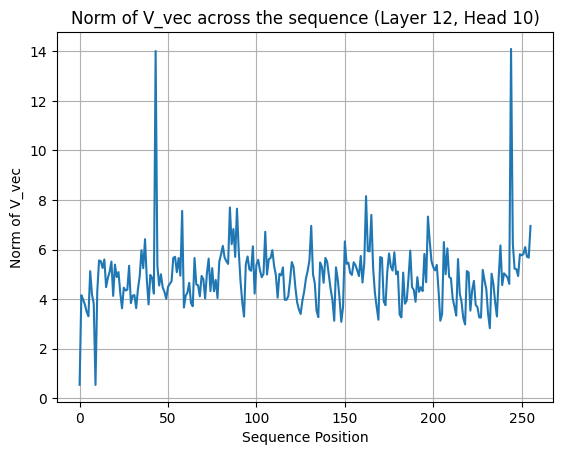

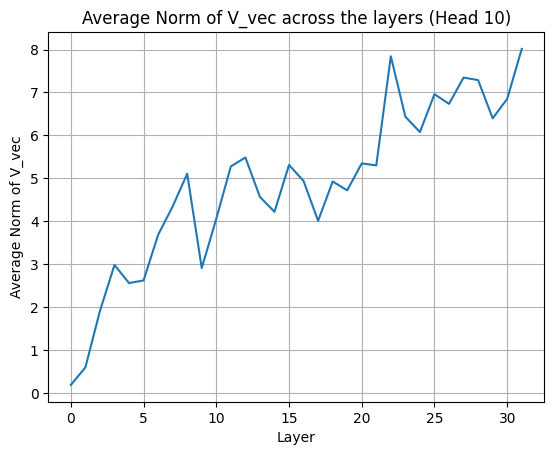

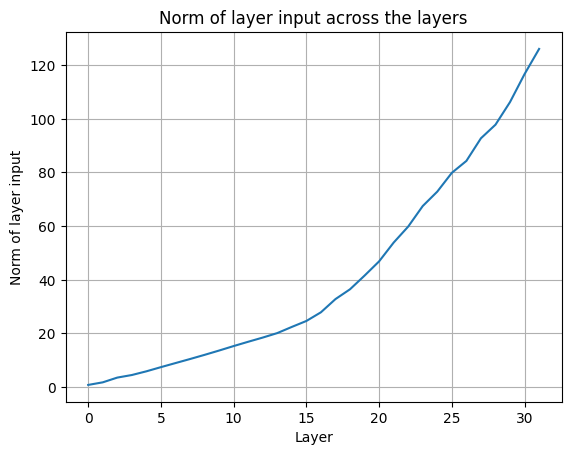

In [4]:
layer = 12
head = 10
V_vec = rope_qkv[layer]['v'][0][head] # Shape (seq_len, head_dim)
print("V_vec shape:", V_vec.shape)
# plot the norm of V_vec across the sequence
V_norm = torch.norm(V_vec[:256], dim=-1) # Shape (seq_len,)
plt.plot(V_norm.cpu().numpy())
plt.title(f"Norm of V_vec across the sequence (Layer {layer}, Head {head})")
plt.xlabel("Sequence Position")
plt.ylabel("Norm of V_vec")
plt.grid()
plt.show()

# average norm of V_vec across the layers. head as example
avg_V_norm = []
avg_input = []
for layer in range(L):
    V_vec = rope_qkv[layer]['v'][0][head] # Shape (seq_len, head_dim)
    V_norm = torch.norm(V_vec, dim=-1) # Shape (seq_len,)
    avg_V_norm.append(V_norm.mean().item())
    avg_input.append(layer_input[layer].norm(dim=-1).mean().item())
plt.plot(avg_V_norm)
plt.title(f"Average Norm of V_vec across the layers (Head {head})")
plt.xlabel("Layer")
plt.ylabel("Average Norm of V_vec")
plt.grid()
plt.show()
plt.plot(avg_input)
plt.title(f"Norm of layer input across the layers")
plt.xlabel("Layer")
plt.ylabel("Norm of layer input")
plt.grid()
plt.show()

In [29]:

def get_attention_map_after_rope(layer_idx, head_idx=0, causal=True, dtype=torch.float32):
    """
    返回: attn [seq_len, seq_len] (softmax 后)
    """
    Q = rope_qkv[layer_idx]['q']  # [B, nh, seq, hd]
    K = rope_qkv[layer_idx]['k']  # [B, nh, seq, hd]

    q = Q[0, head_idx].to(dtype)  # [seq, hd]
    k = K[0, head_idx].to(dtype)  # [seq, hd]
    
    hd = q.shape[-1]
    scores = (q @ k.T) / math.sqrt(hd)  # [seq, seq]

    if causal:
        seq = scores.shape[0]
        mask = torch.triu(torch.ones(seq, seq, device=scores.device, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(mask, float("-inf"))

    attn = torch.softmax(scores, dim=-1)
    if head_idx == 25:
        print("Attention scores (before softmax) for head 25:", scores[:3, :5])
        print("Attention map (after softmax) for head 25:", attn[:3, :5])
    return attn
attention_score = {}
per_token_attention = torch.zeros(inputs['input_ids'].shape[1])  # [seq_len]
avg_t0i = 0
avg_tii = 0
avg_t10 = 0

for head_idx in range(model_config.num_attention_heads):
    attention_score[head_idx] = get_attention_map_after_rope(layer_idx=L-1, head_idx=head_idx, causal=True)
    per_token_attention = per_token_attention + attention_score[head_idx].sum(dim=0)  # 每个 token 的总 attention 权重
    avg_t0i += attention_score[head_idx][:, 0].mean().item() # 每个 token 对第一个 token 的 attention 权重的平均值
    avg_tii += attention_score[head_idx].diagonal().mean().item() # 每个 token 对自己的 attention 权重的平均值
    # [i-10, i] 的 attention 权重的平均值
    avg_t10 += torch.stack([attention_score[head_idx][i, i-10:i].sum() for i in range(10, attention_score[head_idx].shape[1])]).mean().item()
avg_t0i /= model_config.num_attention_heads
avg_tii /= model_config.num_attention_heads
avg_t10 /= model_config.num_attention_heads

print("per_token_attention", per_token_attention[:20])
print("avg_t0i", avg_t0i)
print("avg_tii", avg_tii)
print("avg_t10", avg_t10)

head_idx = 25
print(attn['weights'].shape)
print(attention_score[head_idx].shape)
# print(attention_score[0])
# print(attn['weights'][0][0])
assert torch.allclose(attn['weights'][0][head_idx].to(attention_score[head_idx].dtype), attention_score[head_idx], atol=1e-3)
difference = torch.abs(attn['weights'][0][head_idx].to(attention_score[head_idx].dtype) - attention_score[head_idx]).max()
print("max diff", difference.item())

Attention scores (before softmax) for head 25: tensor([[ 0.2684,    -inf,    -inf,    -inf,    -inf],
        [ 2.6788,  0.0742,    -inf,    -inf,    -inf],
        [ 2.7858, -0.2847, -0.2589,    -inf,    -inf]])
Attention map (after softmax) for head 25: tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.9312, 0.0688, 0.0000, 0.0000, 0.0000],
        [0.9141, 0.0424, 0.0435, 0.0000, 0.0000]])
per_token_attention tensor([4.2970e+04, 6.3508e+01, 7.3902e+01, 9.8864e+01, 3.4580e+01, 6.4898e+01,
        5.4447e+01, 7.1360e+01, 7.6534e+01, 2.4084e+02, 8.1327e+01, 8.1376e+01,
        3.5125e+01, 2.5143e+01, 4.3266e+01, 5.0483e+01, 3.8251e+01, 3.8630e+01,
        3.5168e+01, 7.3621e+01])
avg_t0i 0.3278329891181784
avg_tii 0.054476236866321415
avg_t10 0.09855807345593348
torch.Size([1, 32, 4096, 4096])
torch.Size([4096, 4096])
max diff 0.0009500980377197266


In [13]:
V = rope_qkv[L-1]['v']  # [B, nh, seq, hd]
V = V[0].permute(1, 0, 2).contiguous()  # [seq, nh, hd]
Wo = last_layer_param['self_attn.o_proj.weight'] 
print("V shape", V.shape)
V_concate = V.view(V.shape[0], -1)  # [seq, nh*hd] = [seq, hidden_size]
Outputs = V_concate @ Wo.T  # [seq, hidden_size]
print("Outputs shape", Outputs.shape)


W_head = Wo.T.reshape( model_config.num_attention_heads, -1, model_config.hidden_size)  # [nh, hd, hidden_size]
print("V.shape", V.shape, "W_head.shape", W_head.shape)
output_head = V.permute(1, 0, 2) @ W_head  # [nh, seq, hidden_size]
print("output_head shape", output_head.shape)
sum_head = output_head.sum(dim=0)  # [seq, hidden_size]
# assert torch.allclose(Outputs, sum_head, atol=1e-3)
print("max diff", (Outputs - sum_head).abs().max().item())
# diff 0.125, a little big

V shape torch.Size([4096, 32, 128])
Outputs shape torch.Size([4096, 4096])
V.shape torch.Size([4096, 32, 128]) W_head.shape torch.Size([32, 128, 4096])
output_head shape torch.Size([32, 4096, 4096])
max diff 0.125


In [6]:
# construct the last layer of llama
from transformers.models.llama.modeling_llama import LlamaDecoderLayer
layer = LlamaDecoderLayer(model_config, layer_idx=L-1).half()
missing, unexpected = layer.load_state_dict(last_layer_param, strict=True)
print("missing keys", missing)
print("unexpected keys", unexpected)

missing keys []
unexpected keys []


In [ ]:
layer.eval()
residual = layer_input[L-1] # [1, seq, hidden_size]
attn_output = attn['output'] # [1, seq, nh, hd]
attn_output_concate = attn_output.view(attn_output.shape[0], attn_output.shape[1], -1).contiguous() # [1, seq, hidden_size]
hidden_states = layer.self_attn.o_proj(attn_output_concate)

hidden_states = hidden_states + residual
residual = hidden_states
# hidden_states = layer.post_attention_layernorm(hidden_states)
# hidden_states = layer.mlp(hidden_states)
# hidden_states = residual + hidden_states


In [ ]:
from transformers.models.llama.modeling_llama import LlamaRMSNorm
modelNorm = LlamaRMSNorm(model_config.hidden_size, eps=model_config.rms_norm_eps).half()
modelNorm.load_state_dict({"weight": Wnorm}, strict=True)
hidden_states_normed = modelNorm(hidden_states)
print("hidden_states shape", hidden_states.shape)
logits = hidden_states_normed @ Wlm.T
original_logits = outputs['logits'].cpu()
# assert torch.allclose(logits, original_logits, atol=1e-3)
print("max diff", (logits - original_logits).abs().max().item())


hidden_states shape torch.Size([1, 4096, 4096])


In [16]:
print("Average_diff",(logits - original_logits).abs().mean().item())
# overlap top 10
topk = [1,5,10,50]
for topk in topk:
    topk_indices = torch.topk(logits, k=topk, dim=-1).indices.squeeze(0)  # [seq, topk]
    original_topk_indices = torch.topk(original_logits, k=topk, dim=-1).indices.squeeze(0)  # [seq, topk]

    overlap_counts = []

    for i in range(topk_indices.shape[0]):
        overlap = set(topk_indices[i].tolist()) & set(original_topk_indices[i].tolist())
        overlap_counts.append(len(overlap))
    print(f"Average top-{topk} overlap: {sum(overlap_counts)/len(overlap_counts)/topk}")

Average_diff 2.240234375
Average top-1 overlap: 0.792724609375
Average top-5 overlap: 0.730908203125
Average top-10 overlap: 0.733203125
Average top-50 overlap: 0.7161181640625


In [304]:
"""
test the distribution shift without MLP and LN

"""
from torch.nn import functional as F
diff = torch.empty(19,dtype=torch.float32)
for pos in range(1,20):
    logp = F.log_softmax(logits[:,-pos,:].float(), dim=-1)
    logq = F.log_softmax(original_logits[:,-pos,:].float(), dim=-1)
    eps = 1e-12
    p = logp.exp().clamp_min(eps)
    q = logq.exp().clamp_min(eps)
    skl = 0.5 * (
        (p * (p.log() - q.log())).sum(dim=-1) +
        (q * (q.log() - p.log())).sum(dim=-1)
    )
    diff[pos-1] = skl.item()
print(diff.mean().item())
pos = 13
p = F.softmax(logits[:,-pos,:].float(), dim=-1)
q = F.softmax(original_logits[:,-pos,:].float(), dim=-1)
kl_pq = (p * (p.log() - q.log())).sum(dim=-1)
kl_qp = (q * (q.log() - p.log())).sum(dim=-1)
print(kl_pq, kl_qp)
print(p.argmax(dim=-1), q.argmax(dim=-1))

IndexError: too many indices for tensor of dimension 2

Next: trying to find optimal alpha* for some (head,pos).
we do this in two settings: 1) keep (MLP,norm) and 2) only keep the final RMS norm.

as MLP can cause significant distribution shift in some position, while not in others, we select positions that are less sensetive to mlp.


In [2]:

from transformers.models.llama.modeling_llama import LlamaRMSNorm, LlamaDecoderLayer

device = "cuda"
# constant part
modelNorm = LlamaRMSNorm(model_config.hidden_size, eps=model_config.rms_norm_eps).half().to(device)
modelNorm.load_state_dict({"weight": Wnorm.to(device)}, strict=True)
modelNorm.requires_grad_(False)
modelNorm.eval()

layer = LlamaDecoderLayer(model_config, layer_idx=L-1).half().to(device)
layer.load_state_dict(last_layer_param, strict=True)
layer.eval()
def plain_forward(alpha, head_idx, V_head, pos_list, original, residual_attn_in, Wo, Wlm):
        V_new = alpha.to(V_head.dtype) @ V_head # [n_pos, hd]
        output = original.clone()
        output[head_idx] = V_new
        hidden = output.permute(1,0,2).reshape(len(pos_list), -1) # [n_pos, hidden_size]
        hidden = hidden @ Wo.T # [n_pos, hidden_size]
        hidden = hidden + residual_attn_in # add residual
        
        # hidden = modelNorm(hidden)
        hidden = hidden @ Wlm.T # [n_pos, vocab_size]
        return hidden 

def mlp_forward(alpha, head_idx, V_head, pos_list, original, residual_attn_in, Wo, Wlm):
    V_new = alpha.to(V_head.dtype) @ V_head # [n_pos, hd]
    output = original.clone()
    output[head_idx] = V_new
    hidden = output.permute(1,0,2).reshape(len(pos_list), -1) # [n_pos, hidden_size]
    hidden = hidden @ Wo.T # [n_pos, hidden_size]
    # print("norm compare", hidden.norm().item() / residual_attn_in.norm().item())
    hidden = hidden + residual_attn_in # add residual
   
    residual = hidden
    hidden = layer.post_attention_layernorm(hidden)
    # MLP
    hidden = layer.mlp(hidden)
    hidden = hidden + residual
    
    
    hidden_states_normed = modelNorm(hidden)
    logits = hidden_states_normed @ Wlm.T
    return logits

def residual_forward(alpha, head_idx, V_head, pos_list, original, residual_attn_in, Wo, Wlm):
    V_new = alpha.to(V_head.dtype) @ V_head # [n_pos, hd]
    output = original.clone()
    output[head_idx] = V_new
    hidden = output.permute(1,0,2).reshape(len(pos_list), -1) # [n_pos, hidden_size]
    hidden = hidden @ Wo.T # [n_pos, hidden_size]
    # print("norm compare", hidden.norm().item() / residual_attn_in.norm().item())
    hidden = residual_attn_in # add residual
   
    residual = hidden
    hidden = layer.post_attention_layernorm(hidden)
    # MLP
    hidden = layer.mlp(hidden)
    hidden = hidden + residual
    
    
    hidden_states_normed = modelNorm(hidden)
    logits = hidden_states_normed @ Wlm.T
    return logits

def optimize_alpha_star(function ,head_idx, pos_list ,training_steps=100, lr=0.5, device="cuda"):
    """
    head: int, the head to optimize
    pos_list: list of int, the positions to optimize
    """
    # a[n_pos,seq]
    n_pos = len(pos_list)
    # a_param = torch.zeros(n_pos, 4096, device=device, requires_grad=True)
    a_param = torch.nn.Parameter(torch.randn(n_pos, 4096, device=device) * 0.1)
    
    mask = torch.zeros(n_pos, 4096, device=device)
    for i, pos in enumerate(pos_list):
        mask[i, pos+1:] = float("-inf")
    
    gt_y = gt_label[0, pos_list].to(device)
    
    opt = torch.optim.Adam([a_param], lr=lr)
    
    # compute the constant part
    residual_attn_in = layer_input[L-1][0,pos_list].to(device) # [n_pos, hidden_size]
    original = attn['output'][0,pos_list].permute(1,0,2).to(device) # [nh, n_pos, hd]
    V_head = rope_qkv[L-1]['v'].to(device)[0][head_idx]  # [B, nh, seq, hd]
    Wo = last_layer_param['self_attn.o_proj.weight'].to(device)
    Wlm = kv["Wlm"].to(device)
    
    # def head_ablate_loss(head):
    #     output = original.clone()
    #     output[head].zero_()   # 或者 output[head] = 0
    #     hidden = output.permute(1,0,2).reshape(n_pos, -1)
    #     hidden = hidden @ Wo.T
    #     hidden = hidden + residual_attn_in
    #     residual = hidden
    #     hidden = layer.post_attention_layernorm(hidden)
    #     hidden = layer.mlp(hidden) + residual
    #     logits = modelNorm(hidden) @ Wlm.T
    #     return F.cross_entropy(logits.float(), gt_y).item()
    # return head_ablate_loss(head_idx)
    losses = []
    for step in range(training_steps):
        alpha = F.softmax(a_param + mask, dim=-1)    
        
        logits = function(alpha, head_idx, V_head, pos_list, original, residual_attn_in, Wo, Wlm)
        loss = F.cross_entropy(logits.float(), gt_y, reduction='mean')
        losses.append(loss.item())
        if step % 10 == 0:
            print("step", step, "loss:", loss.item())
        opt.zero_grad()
        loss.backward()
        opt.step()
    return F.softmax(a_param + mask, dim=-1).detach(),losses


head_idx = 25
pos_list = list(range(4096-128, 4096))
func = mlp_forward
a_star,loss = optimize_alpha_star(func, head_idx=head_idx, pos_list=pos_list, training_steps=100, lr=0.5, device=device)
func = mlp_forward
a_star_2,loss_2 = optimize_alpha_star(func, head_idx=head_idx, pos_list=pos_list, training_steps=100, lr=0.5, device=device)
# func = residual_forward
# a_star_3,loss_3 = optimize_alpha_star(func, head_idx=head_idx, pos_list=pos_list, training_steps=100, lr=0.5, device=device)
# for head_idx in range(25,model_config.num_attention_heads):
#     pos_list = list(range(4096-128, 4096))
#     loss = optimize_alpha_star(head_idx=head_idx, pos_list=pos_list, training_steps=100, lr=0.5, device=device)
#     print(f"head {head_idx} ablation loss", loss)

step 0 loss: 1.7494909763336182
step 10 loss: 1.6897881031036377
step 20 loss: 1.6353156566619873
step 30 loss: 1.604274034500122
step 40 loss: 1.598264217376709
step 50 loss: 1.5982427597045898
step 60 loss: 1.5983107089996338
step 70 loss: 1.5983726978302002
step 80 loss: 1.598196029663086
step 90 loss: 1.598180890083313
step 0 loss: 1.7495073080062866
step 10 loss: 1.6895275115966797
step 20 loss: 1.6346465349197388
step 30 loss: 1.6043442487716675
step 40 loss: 1.598514199256897
step 50 loss: 1.5983226299285889
step 60 loss: 1.5982695817947388
step 70 loss: 1.5982089042663574
step 80 loss: 1.5981842279434204
step 90 loss: 1.5982823371887207


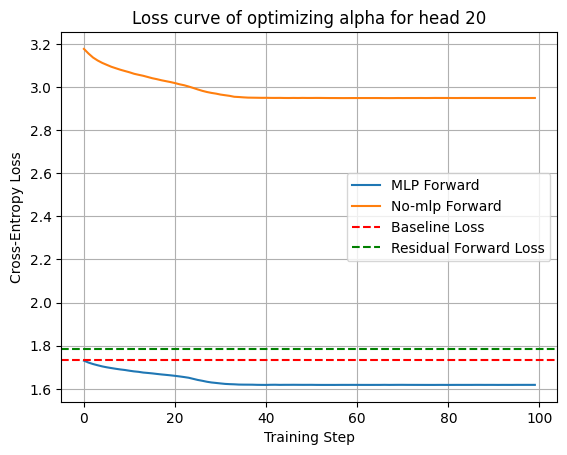

In [24]:
vanilla = outputs["logits"]
vanilla_logits = vanilla[0][pos_list]
loss_baseline = F.cross_entropy(vanilla_logits.float(), gt_label[0, pos_list].to(vanilla_logits.device), reduction='none')
residual_baseline = loss_3[0]
# plot loss and loss curve
plt.plot(loss, label="MLP Forward")
plt.plot(loss_2, label="No-mlp Forward")
plt.axhline(loss_baseline.mean().item(), color='red', linestyle='--', label="Baseline Loss")
plt.axhline(residual_baseline, color='green', linestyle='--', label="Residual Forward Loss")
plt.title(f"Loss curve of optimizing alpha for head {head_idx}")
plt.xlabel("Training Step")
plt.ylabel("Cross-Entropy Loss")
plt.grid()
plt.legend()
plt.show()

entrophy 0.4588106870651245
attn_entrophy 2.841796875
top1_mass 0.8616229295730591


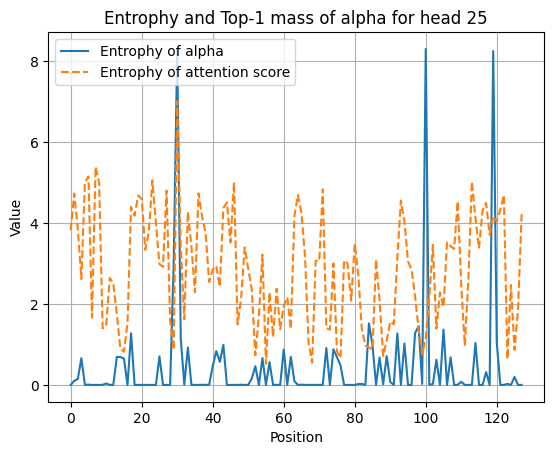

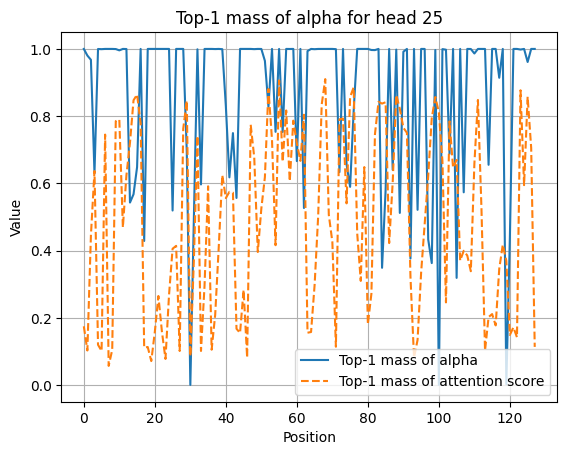

In [ ]:
from turtle import color


entrophy = -(a_star * a_star.clamp_min(1e-8).log()).sum(dim=-1)
print("entrophy", entrophy.mean().item())

attn_score = attn['weights'][0][head_idx, pos_list]
attn_entrophy = -(attn_score * attn_score.clamp_min(1e-6).log()).sum(dim=-1)
print("attn_entrophy", attn_entrophy.mean().item())
topk = 1
topk_mass = a_star.topk(topk, dim=-1).values.sum(dim=-1)
attn_topk_mass = attn_score.topk(topk, dim=-1).values.sum(dim=-1)
print("top{}_mass".format(topk), topk_mass.mean().item())
# plot the entrophy 
plt.plot(entrophy.cpu().numpy(), label="Entrophy of alpha", linestyle='-', color='C0')
plt.plot(attn_entrophy.cpu().numpy(), label="Entrophy of attention score",color='C1', linestyle='--')
plt.title(f"Entrophy mass of alpha for head {head_idx}")
plt.xlabel("Position")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()


# plot the topk mass
plt.plot(topk_mass.cpu().numpy(), label="Top-{} mass of alpha".format(topk), linestyle='-', color='C0')
plt.plot(attn_topk_mass.cpu().numpy(), label="Top-{} mass of attention score".format(topk),color='C1', linestyle='--')
plt.title(f"Top-{topk} mass of alpha for head {head_idx}")
plt.xlabel("Position")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()


KL(a_star || vanilla_alpha) 9.494295120239258
KL(vanilla_alpha || a_star) 21.97977066040039


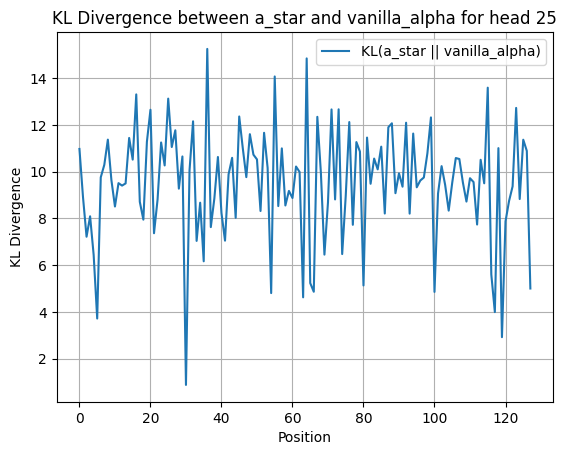

In [13]:
vanilla_alpha = attn['weights'][0][head_idx, pos_list].float().to(device)
def KL_divergence(p, q):
    eps = 1e-12
    p = p.clamp_min(eps)
    q = q.clamp_min(eps)
    kl_pq = (p * (p.log() - q.log())).sum(dim=-1)
    kl_qp = (q * (q.log() - p.log())).sum(dim=-1)
    return kl_pq, kl_qp
kl_pq, kl_qp = KL_divergence(a_star, vanilla_alpha)
print("KL(a_star || vanilla_alpha)", kl_pq.mean().item())
print("KL(vanilla_alpha || a_star)", kl_qp.mean().item())

# kl_pq, kl_qp = KL_divergence(a_star, a_star_2)
# print("KL(a_star || a_star_2)", kl_pq.mean().item())
# print("KL(a_star_2 || a_star)", kl_qp.mean().item())
# plot the KL divergence across the sequence
plt.plot(kl_pq.cpu().numpy(), label="KL(a_star || vanilla_alpha)")
# plt.plot(kl_qp.cpu().numpy(), label="KL(vanilla_alpha || a_star)")
plt.title(f"KL Divergence between a_star and vanilla_alpha for head {head_idx}")
plt.xlabel("Position")
plt.ylabel("KL Divergence")
plt.legend()
plt.grid()
plt.show()

In [14]:

def topk_overlap(p, q, topk=10):
    p_topk_indices = torch.topk(p, k=topk, dim=-1).indices  # [n_pos, topk]
    q_topk_indices = torch.topk(q, k=topk, dim=-1).indices  # [n_pos, topk]

    overlap_counts = []

    for i in range(p_topk_indices.shape[0]):
        overlap = set(p_topk_indices[i].tolist()) & set(q_topk_indices[i].tolist())
        overlap_counts.append(len(overlap))
    print("overlap_counts", overlap_counts)
    return overlap_counts

topk=5
overlap_counts = topk_overlap(a_star, vanilla_alpha, topk=topk) 
print("Average top-{} overlap: {}".format(topk, sum(overlap_counts)/len(overlap_counts)/topk))
# print("Average top-{} overlap: {}".format(topk, topk_overlap(a_star, a_star_2, topk=topk)))



overlap_counts [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
Average top-5 overlap: 0.0125


In [330]:


head = head_idx
V = rope_qkv[L-1]['v'].float().to(device)  # [B, nh, seq, hd]
V_head = V[0][head]  # [seq, hd]
V_1 = a_star @ V_head
V_2 = a_star_2 @ V_head
V_3 = vanilla_alpha @ V_head
cos = F.cosine_similarity(V_1, V_2, dim=-1)          # [n_pos]
rel = (V_1 - V_2).norm(dim=-1) / (V_1.norm(dim=-1) + 1e-12)
print(cos)
print("mix cosine mean/med:", cos.mean().item(), cos.median().item())
print("mix relerr mean/med:", rel.mean().item(), rel.median().item())
cos_vanilla = F.cosine_similarity(V_1, V_3, dim=-1)
rel_vanilla = (V_1 - V_3).norm(dim=-1) / (V_1.norm(dim=-1) + 1e-12)
print("vanilla cosine mean/med:", cos_vanilla.mean().item(), cos_vanilla.median().item())
print("vanilla relerr mean/med:", rel_vanilla.mean().item(), rel_vanilla.median().item())

diff_cos_pos = (cos < 0.9).nonzero().squeeze(-1)
print("diff_cos_pos", diff_cos_pos)


tensor([0.9999, 0.8869, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.9967,
        1.0000, 0.9937, 1.0000, 0.9966, 1.0000, 0.9993, 1.0000, 1.0000, 1.0000,
        1.0000, 0.9998, 1.0000, 0.9998, 1.0000, 0.9999, 0.9999, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 0.9999, 1.0000, 1.0000, 1.0000, 1.0000, 0.9952,
        1.0000, 1.0000, 1.0000, 0.8219, 0.8335, 0.9995, 1.0000, 1.0000, 0.9998,
        0.9999, 1.0000, 0.9995, 1.0000, 1.0000, 1.0000, 0.9991, 1.0000, 0.9997,
        1.0000, 1.0000, 0.3097, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        0.2912, 0.9982, 1.0000, 0.9641, 1.0000, 1.0000, 0.9997, 0.9995, 0.9999,
        1.0000, 0.9999, 1.0000, 0.9984, 0.9984, 1.0000, 1.0000, 1.0000, 0.9964,
        1.0000, 1.0000, 1.0000, 1.0000, 0.9842, 0.9981, 1.0000, 1.0000, 0.9850,
        0.9999, 1.0000, 1.0000, 0.9999, 1.0000, 0.9926, 0.9941, 0.9999, 0.9861,
        0.9821, 1.0000, 1.0000, 1.0000, 1.0000, 0.9991, 1.0000, 1.0000, 1.0000,
        0.9929, 1.0000, 1.0000, 0.9999, 

In [ ]:
torch.set_printoptions(sci_mode=False)

vanilla = outputs["logits"]
vanilla_logits = vanilla[0][pos_list]
loss_baseline = F.cross_entropy(vanilla_logits.float(), gt_label[0, pos_list].to(vanilla_logits.device), reduction='none')
print("baseline loss", loss_baseline.mean().item())

device='cuda'
a_star = a_star.to(device)
residual_attn_in = layer_input[L-1][0,pos_list].to(device) # [n_pos, hidden_size]
original = attn['output'][0,pos_list].permute(1,0,2).to(device) # [nh, n_pos, hd]
V_head = rope_qkv[L-1]['v'].to(device)[0][head_idx]  # [B, nh, seq, hd]
Wo = last_layer_param['self_attn.o_proj.weight'].to(device)
Wlm = kv["Wlm"].to(device)

logits = mlp_forward(a_star, head_idx, V_head, pos_list, original, residual_attn_in, Wo, Wlm)
loss_mix = F.cross_entropy(logits.float(), gt_label[0, pos_list].to(logits.device), reduction='none')
print("mix loss", loss_mix.mean().item())

logits_2 = mlp_forward(a_star_2.to(device), head_idx, V_head, pos_list, original, residual_attn_in, Wo, Wlm)
loss_mix_2 = F.cross_entropy(logits_2.float(), gt_label[0, pos_list].to(logits_2.device), reduction='none')
print("mix_2 loss", loss_mix_2.mean().item())

eps = 1e-5

# print(loss_baseline[diff_cos_pos].mean().item(), loss_baseline[diff_cos_pos].max().item(),loss_baseline)
print(loss_mix[diff_cos_pos].mean().item(), loss_mix[diff_cos_pos].max().item(),loss_mix[diff_cos_pos])

baseline loss 1.7316447496414185
mix loss 1.6329621076583862
mix_2 loss 1.633148431777954
0.03299250453710556 0.1810423582792282 tensor([0.0075, 0.1810, 0.0064, 0.0017, 0.0012, 0.0002], device='cuda:0',
       grad_fn=<IndexBackward0>)


Cluster sizes:
[384 175 446 257 170 379 174 182 314 166 301 331 139 361 132 185]
tensor([[3.5736e-02, 2.6822e-06, 3.9339e-06, 6.6996e-04, 3.3200e-05, 8.8036e-05,
         2.1279e-05, 3.3379e-06, 2.8610e-06, 5.8293e-05, 4.9472e-06, 1.6999e-04,
         9.0003e-06, 1.3947e-05, 8.2850e-06, 1.1325e-06, 1.1921e-06, 4.2319e-06,
         1.7881e-06, 1.3113e-06],
        [9.6191e-02, 1.6987e-05, 2.5332e-05, 1.7776e-03, 1.3113e-04, 3.6788e-04,
         1.0502e-04, 2.1696e-05, 1.6809e-05, 9.6321e-05, 2.9504e-05, 6.4087e-04,
         4.5002e-05, 8.2731e-05, 5.0008e-05, 8.1658e-06, 1.2040e-05, 2.9266e-05,
         1.2696e-05, 1.6093e-05],
        [4.4580e-01, 1.2279e-05, 4.5538e-05, 1.3561e-03, 1.0836e-04, 3.4285e-04,
         1.3530e-04, 3.0935e-05, 1.9193e-05, 3.8099e-04, 2.7835e-05, 3.2592e-04,
         2.9981e-05, 5.9128e-05, 3.0816e-05, 8.9407e-06, 1.7345e-05, 9.4473e-05,
         2.7835e-05, 3.5167e-05]], device='cuda:0')
Cluster a_star entrophy 0.30542635917663574
Cluster attention score en

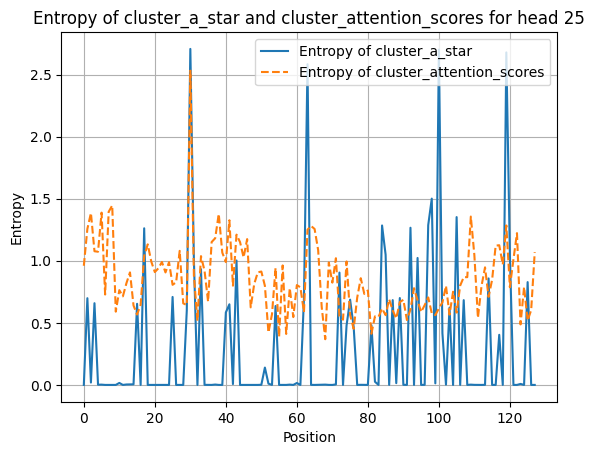

In [ ]:
from matplotlib import axis
from sklearn.cluster import KMeans
import numpy as np
def clustering(layer_idx, head_idx=0, key_type='k', n_clusters=5):
    key = rope_qkv[layer_idx][key_type] # [B,nh,seq_len,hd]
    specific_head_key = key[0, head_idx, :, :] # [seq_len, head_dim]
    key = F.normalize(specific_head_key.float(), dim=-1).cpu().numpy()
    labels = KMeans(n_clusters=n_clusters, random_state=0).fit_predict(key)
    print("Cluster sizes:")
    print(np.bincount(labels))

    return labels

num_clusters = 16
labels = clustering(layer_idx=L-1, head_idx=head_idx, key_type='k', n_clusters=16)
# plot the inter-cluster attention score concentration
cluster_a_star = []
cluster_attention_scores = []
for i in range(num_clusters):
    cluster_positions = np.where(labels == i)[0]
    cluster_a_star.append(a_star[:, cluster_positions].sum(axis=1))  # [n_pos, cluster_len] -> [n_pos]
    cluster_attention_scores.append(vanilla_alpha[:, cluster_positions].sum(axis=1))  # [n_pos]
# plot the entropy of cluster_a_star and cluster_attention_scores
cluster_a_star = torch.stack(cluster_a_star, dim=1)  # [n_pos, num_clusters]
cluster_attention_scores = torch.stack(cluster_attention_scores, dim=1)  # [n_pos, num_clusters]
cluster_a_star_entrophy = -(cluster_a_star * cluster_a_star.clamp_min(1e-8).log()).sum(dim=-1)
cluster_attention_entrophy = -(cluster_attention_scores * cluster_attention_scores.clamp_min(1e-8).log()).sum(dim=-1)
print("Cluster a_star entrophy", cluster_a_star_entrophy.mean().item())
print("Cluster attention score entrophy", cluster_attention_entrophy.mean().item())
plt.plot(cluster_a_star_entrophy.cpu().numpy(), label="Entropy of cluster_a_star", linestyle='-', color='C0')
plt.plot(cluster_attention_entrophy.cpu().numpy(), label="Entropy of cluster_attention_scores", color='C1', linestyle='--')
plt.title(f"Entropy of cluster_a_star and cluster_attention_scores for head {head_idx}")
plt.xlabel("Position")
plt.ylabel("Entropy")
plt.legend()
plt.grid()
plt.show()